# 5.3 MIND 多兴趣召回

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

当用户同时喜欢科幻、跑步和烹饪时，为什么一个平均向量会丢失兴趣？如何用多个向量分别检索？

## Setup

本 Notebook 的默认真实数据是 **Amazon Books 2014：按 MIND 论文协议（item-first 单遍 10-core）执行，并核验 6,271,511 行**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。

**主要资料：** [Li et al., 2019, MIND](https://arxiv.org/abs/1904.08030)

In [1]:
from pathlib import Path
import os, sys, json
import torch
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = Path(os.environ.get("RECSYS_ARTIFACT_ROOT", PROJECT_ROOT)).expanduser().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("RECSYS_PROFILE", "full")
PROFILE = os.environ["RECSYS_PROFILE"]
CUDA_AVAILABLE = torch.cuda.is_available()
DATASET_KEY = "mind-amazon-books"
# Setup 只声明执行边界。完整数据由章节 runner 在 Train & Inference 单元按需读取，
# 避免仅打开 Notebook 就解析数千万行文件。
REAL_DATASET = {
    "dataset": DATASET_KEY,
    "profile": PROFILE,
    "loading": "lazy: chapter runner owns loading and returns executed provenance",
    "randomly_fabricated_rows": 0,
}
print({"profile": PROFILE, "project_root": str(PROJECT_ROOT), "artifact_root": str(ARTIFACT_ROOT), "dataset_boundary": REAL_DATASET,
       "cuda_available": CUDA_AVAILABLE,
       "cuda_device": torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'project_root': '<ARTIFACT_ROOT>', 'artifact_root': '<ARTIFACT_ROOT>', 'dataset_boundary': {'dataset': 'mind-amazon-books', 'profile': 'smoke', 'loading': 'lazy: chapter runner owns loading and returns executed provenance', 'randomly_fabricated_rows': 0}, 'cuda_available': False, 'cuda_device': None}


## 学习地图

1. 从原始论文理解系统约束；
2. 用可手算数字读懂公式和形状；
3. 检查数据、切分与标签；
4. 使用工业框架模型类训练；
5. 分开验证训练、推理和测试；
6. 用实际输出讨论失败边界。

**本节问题：** 当用户同时喜欢科幻、跑步和烹饪时，为什么一个平均向量会丢失兴趣？如何用多个向量分别检索？

**阅读约定：** 通用数学通过 3.0 基础课程链接回看；本页只详细推导论文引入或改造的数学。第一次阅读先追踪输入、输出和形状，再看梯度。

## Paper & Context

MIND 从 Tmall 的匹配阶段出发：一个用户可能同时关心服饰、运动和食品，而单个平均向量会把不同方向混在一起。论文把行为转为多个兴趣胶囊；训练时目标物品通过 label-aware attention 选择应监督的兴趣，服务时则移除这层，让多个兴趣各自 ANN。原文还给出随机 19:1 离线切分和一周线上 A/B；本教程的时间切分是更严格的迁移协议，不能把两套数值直接相减。

**来源：** [Li et al., 2019, MIND](https://arxiv.org/abs/1904.08030)

### 原文实验设计与关键结论

原文对 Amazon Books 做 user/item 10-core 后得到 351,356 用户、393,801 商品、6,271,511 行，并随机按 19:1 划分，再用 HitRate@10/50/100 比较方法。Amazon 上 K=3、d=36 的 MIND-K HR@10 为 0.0309，YouTube DNN 为 0.0231。full 档恢复数据版本与统计，但教程使用更严格的时间协议；只有明确对齐的字段才允许对照，smoke 不参与。

请区分三层证据：论文中的离线实验、本 Notebook 验证的代码链路、生产系统尚需验证的在线收益。三者不能互相替代。

## Reproduction Contract

**正式数据：** Amazon Books ratings-only 2014, item-first single-pass 10-core  
**资源 ID：** `amazon-books-2014-ratings`  
**切分：** paper protocol: random 19:1 train/test; a deterministic seed records the sampled target  
**指标：** HitRate@10, HitRate@50, HitRate@100  
**与论文比较边界：** 样本行数与论文 Table 1/2 完全一致（6,271,511），以行数为比较锚点；论文 users/items（351,356/393,801）与可复现口径（218,972/369,114）不同，不作硬校验

`full` 只有在运行输出证明数据、切分、候选集、模型配置与指标均对齐时，才可能进入论文数值比较；它不是把教学适配器自动变成论文复现的开关。`smoke` 只做张量、损失和推理链路回归。

## Model Structure & Formula Walkthrough

![Figure 2 · MIND overview](/static/paper-figures/mind.webp)

> **论文原图节选** · Figure 2 · MIND overview · PDF p.3。下图直接截取自原文，用于对照下方公式与代码。

### 关键模块

- **行为 Embedding + Pooling**：把每次点击的物品 id / 类别 embedding 平均成行为向量，而不是一开始就压成一个用户向量。
- **动态路由胶囊**：多轮“投票”：相似行为反复把票投给同一个兴趣胶囊，最终得到 K 个兴趣向量（而不是 1 个）。
- **Label-aware Attention**：训练时用目标物品做 query、从 K 个兴趣中选最相关的一个；推理时让 K 个兴趣各自召回再合并。

### 结构：一段历史变成多个兴趣向量

先说人话：每条历史行为都可以给 K 个“兴趣小组”投票，而且不是非黑即白地只进一组。历史商品 embedding 组成 $H\in\mathbb R^{B\times L\times d}$：$B$ 是用户数，$L$ 是保留的历史长度，$d$ 是每件商品的坐标维度。输出是 $[B,K,d]$，表示每位用户有 K 支兴趣箭头。

| 符号 | 含义 | 形状 |
|---|---|---|
| $h_j$ | 第 $j$ 条历史行为向量 | $[d]$ |
| $b_{jk}$ | 行为 $j$ 投给兴趣 $k$ 的未归一化票数 | 标量 |
| $c_{jk}$ | 对固定 $j$ 经 softmax 后的路由权重 | 标量，$\sum_k c_{jk}=1$ |
| $s_k$ | 兴趣 $k$ 收到的行为加权和 | $[d]$ |
| $v_k$ | squash 后的第 $k$ 个兴趣向量 | $[d]$ |
| $e_i$ | 训练目标或候选物品向量 | $[d]$ |
| $a_k$ | 目标物品对兴趣 $k$ 的 Label-aware 权重 | 标量，$\sum_k a_k=1$ |

动态路由维护行为 $j$ 到兴趣胶囊 $k$ 的权重 $c_{jk}=\mathrm{softmax}_k(b_{jk})$。对固定行为 j，所有 $c_{jk}$ 的和为 1；先加权汇总 $s_k=\sum_jc_{jk}h_j$，再用 squash 保留方向并把长度限制在 0～1：

$$v_k=\frac{\|s_k\|^2}{1+\|s_k\|^2}\frac{s_k}{\|s_k\|},\qquad b_{jk}\leftarrow b_{jk}+h_j^\top v_k.$$

当 $\|s_k\|$ 很小时，前面的比例接近 0；有很多一致行为时，长度逐渐接近 1。更新式表示：行为 j 与兴趣 k 越同向，下一轮越愿意把票投给它。

训练时才使用目标商品做 **Label-aware Attention**。先算匹配分 $r_k=v_k^\top e_i$，再归一化：

$$a_k=\frac{\exp(r_k^p)}{\sum_{q=1}^{K}\exp(r_q^p)},\qquad v_u=\sum_{k=1}^{K}a_kv_k.$$

$p$ 控制选择有多“硬”：$p$ 增大时，最高分兴趣更接近独占监督；权重始终和为 1。若两个兴趣分数是 $(2,1)$、取 $p=1$，权重约为 $(0.731,0.269)$。选出训练用户向量后，对一个正物品 $i^+$ 和采到的负物品集合 $\mathcal N$ 优化 sampled-softmax：

$$L=-\log\frac{\exp(v_u^\top e_{i^+})}{\exp(v_u^\top e_{i^+})+\sum_{j\in\mathcal N}\exp(v_u^\top e_j)}.$$

正物品分数上升会增大分子占比，负物品分数上升会增大分母并受罚。这里的“label-aware”也划出边界：线上没有目标标签，不能先偷看候选来生成用户兴趣；服务时必须让 K 个兴趣分别 ANN，再合并、去重与限额。

```text
history [B,L,d] -> routing -> interests [B,K,d] -> K-way ANN -> merge
```

### 公式到代码

`run_mind` 把真实时间序列整理为定长张量；Torch-RecHub 的 CapsuleNetwork 完成路由，训练标签只用于选择兴趣而不会进入线上用户特征。

阅读源码时按“张量形状 → 前向计算 → score → loss → metric”五步追踪，不需要一次读完整个工程文件。

## Math by Hand

### 通用先修（先回看 3.0 基础课程）

- [隐式反馈与未观察物品](/notebooks/3_2_data_ml_basics#implicit-feedback)
- [张量形状与轴](/notebooks/3_3_linear_algebra#tensors-shapes)
- [向量模长、点积与加权和](/notebooks/3_3_linear_algebra#elementwise-dot)
- [Softmax 与温度](/notebooks/3_6_information_theory#softmax-temperature)

### 本论文新增数学（本节详细推导）

胶囊动态路由（squash 与投票更新）、归一化 Label-aware Attention，以及候选采样下的 sampled-softmax。

设四条历史在二维图上是 $(1,0.1),(0.9,0.2),(0.1,1),(0.2,0.9)$。全部平均得到 $(0.55,0.55)$，它既不像横向兴趣也不像纵向兴趣；分成两组后，两个中心约为 $(0.95,0.15)$ 与 $(0.15,0.95)$。MIND 用可学习的软分组代替手工分组：每条行为对 K 个兴趣都有权重，权重经 softmax 后和为 1，再对行为向量做加权和。候选 $e_i$ 的服务分数取 $\max_k v_k^\top e_i$。

下面用 NumPy/Matplotlib 验证直觉。二维图只是教学投影，工业 embedding 虽有更多维，计算规则相同。

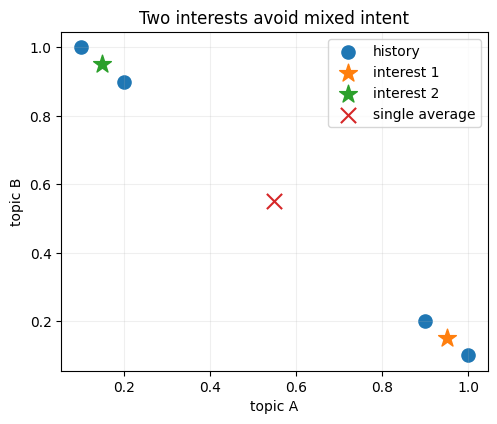

{'interest_1': [0.95, 0.15000000000000002], 'interest_2': [0.15000000000000002, 0.95], 'single': [0.55, 0.55]}


In [2]:
import numpy as np, matplotlib.pyplot as plt
history=np.array([[1,.1],[.9,.2],[.1,1],[.2,.9]])
a,b,single=history[:2].mean(0),history[2:].mean(0),history.mean(0)
fig,ax=plt.subplots(figsize=(5.5,4.4)); ax.scatter(history[:,0],history[:,1],s=90,label='history')
ax.scatter(*a,s=180,marker='*',label='interest 1'); ax.scatter(*b,s=180,marker='*',label='interest 2')
ax.scatter(*single,s=120,marker='x',label='single average'); ax.set(title='Two interests avoid mixed intent',xlabel='topic A',ylabel='topic B')
ax.legend(); ax.grid(alpha=.2); plt.show()
print({'interest_1':a.tolist(),'interest_2':b.tolist(),'single':single.tolist()})

## Data

### 权威 full 协议（效果验收目标）

**正式数据：** Amazon Books ratings-only 2014, item-first single-pass 10-core  
**资源 ID：** `amazon-books-2014-ratings`  
**切分：** paper protocol: random 19:1 train/test; a deterministic seed records the sampled target  
**指标：** HitRate@10, HitRate@50, HitRate@100  
**与论文比较边界：** 样本行数与论文 Table 1/2 完全一致（6,271,511），以行数为比较锚点；论文 users/items（351,356/393,801）与可复现口径（218,972/369,114）不同，不作硬校验

### smoke 教学适配器（默认 runner 实际读取）

仓库随附的真实 Amazon 评分教学子集；从每位用户的已观察序列构造 next-item 正例，并从其未观察目录中确定性采负例。它不满足论文的 10-core 后统计，只验证 `[B,L] -> [B,K,d]` 与多兴趣检索链路。

下方运行结果打印的 provenance 才是本次执行事实；若资源、统计或切分与 full 协议不一致，就必须标记为不可比较。

**防泄漏清单：**按时间切分；item 映射只表达已知目录，不读取测试标签；低评分或未点击负反馈均来自数据中的已观察行；序列只看预测时刻以前；测试集只在最后评价。CPU 档使用真实数据的确定性子集，**不是统一 benchmark 成绩**。

## Model & Framework

实际使用 torch_rechub.models.matching.MIND，执行 CapsuleNetwork、目标兴趣选择和多兴趣推理；full profile 映射 TorchEasyRec MIND。

smoke 档强调模型类、张量契约和指标链路真实可运行；full 档应替换原始数据、分布式配置、索引/服务和资源预算，而不是只增加 epoch。

In [3]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from importlib import import_module
from recsys_lab.runtime import print_progress, save_records

# 算法实现就在当前章节目录，不再通过公共模块隐藏。
chapter_train = import_module("chapter_code.5_3_mind.train")
run_mind = chapter_train.run_mind

print("实际执行函数源码（包含数据、训练、推理和测试）：")
print(inspect.getsource(run_mind))

实际执行函数源码（包含数据、训练、推理和测试）：
def run_mind(epochs: int = 26, *, progress: ProgressCallback | None = None) -> dict:
    # 1) 固定参数初始化，并读取本章指定的真实数据切片。
    emit_progress(progress, stage="data_prepare", current=0, total=1, message="加载数据并构造 MIND 序列")
    seed_everything(); ratings, provenance = _real_amazon()
    rows = _mind_rows(ratings); n_users, n_items = ratings.user_id.nunique(), ratings.item_id.nunique(); history_length = 10
    embedding_dim = 36 if full_profile() else 12
    interest_num = 3 if full_profile() else 2
    user_feature = [SparseFeature("user_id", n_users + 1, embedding_dim)]
    item_feature = [SparseFeature("item_id", n_items + 1, embedding_dim, padding_idx=0)]
    history_feature = [SequenceFeature("history", n_items + 1, embedding_dim, pooling="concat", shared_with="item_id", padding_idx=0)]
    negative_feature = [SequenceFeature("negative_items", n_items + 1, embedding_dim, pooling="concat", shared_with="item_id", padding_idx=0)]
    # 2) 按论文结构实例化模型；这里是理解层尺寸和特征契约的入口。
 

## Train & Inference

下一格固定 seed、构造数据、实例化模型、训练并进入推理路径。生成式章节在 CUDA 上执行完整评测；CPU 环境只验证缩小后的基本张量与约束链路。

In [4]:
result = run_mind(progress=print_progress)
REAL_DATASET = result['dataset']
assert REAL_DATASET['randomly_fabricated_rows'] == 0
print({'framework': result['framework'], 'dataset': result.get('dataset', {}),
       'device': result.get('device'), 'validation_mode': result.get('validation_mode')})
print('inference contract:', 'user tower 输出 [B,K,d]；每个兴趣独立检索，再按最高分合并、去重和配额控制。')
assert np.isfinite(result['loss_curve']).all()
print('loss:', round(result['loss_curve'][0],4), '→', round(result['loss_curve'][-1],4))

[data_prepare] 0/1 加载数据并构造 MIND 序列


[data_prepare] 1/1 sequence_users=128


[train] 0/26 训练多兴趣网络


[train] 2/26


[train] 4/26


...

[inference] 2/3


[inference] 3/3


[evaluate] 0/1 计算采样排序指标


[evaluate] 1/1 recall@10=0


{'framework': 'torch_rechub.models.matching.MIND', 'dataset': {'dataset': 'Amazon Reviews 2023 / Video Games / 5-core', 'source': 'https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/benchmark/5core/rating_only/Video_Games.csv.gz', 'source_sha256': 'a2bde5f3b945960d161538c200dd87845e6ee471b46da96410dde61613c6901c', 'slice_rule': 'top 500 users by observed interaction count; ties by user_id; all their rows retained', 'profile': 'smoke', 'local_resource': '<ARTIFACT_ROOT>/data/amazon-reviews-2023-video-games/interactions.csv', 'rows_used': 16172, 'users_used': 128, 'items_used': 7392, 'time_min_utc': '2000-09-17T21:55:58+00:00', 'time_max_utc': '2023-05-31T16:03:41+00:00', 'positive_rule': 'observed Amazon rating >= 4.0', 'randomly_fabricated_rows': 0, 'sequence_users': 128, 'history_length': 10, 'negative_source': 'sampled unobserved catalog items'}, 'device': None, 'validation_mode': None}
inference contract: user tower 输出 [B,K,d]；每个兴趣独立检索，再按最高分合并、去重和配额控制。
loss: 1.8248 → 0.869

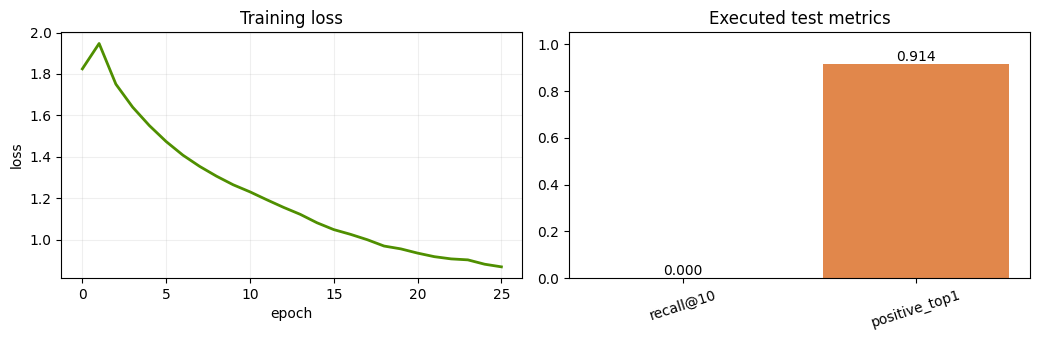

,value
recall@10,0.000000
positive_top1,0.914062


In [5]:
fig,axes=plt.subplots(1,2,figsize=(10.5,3.5))
axes[0].plot(result['loss_curve'],color='#4f8f00',lw=2); axes[0].set(title='Training loss',xlabel='epoch',ylabel='loss'); axes[0].grid(alpha=.2)
metrics={'recall@10': result['recall@10'], 'positive_top1': result['positive_top1']}
axes[1].bar(range(len(metrics)),list(metrics.values()),color=['#7ca832','#e1874b','#6d88a4'][:len(metrics)])
axes[1].set_xticks(range(len(metrics)),list(metrics),rotation=18); axes[1].set(title='Executed test metrics',ylim=(0,max(1.0,max(metrics.values())*1.15)))
for index,value in enumerate(metrics.values()): axes[1].text(index,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show(); display(pd.Series(metrics,name='value').to_frame())

In [6]:
# 论文数字只能在数据、切分、候选和指标全部同口径时相减。
paper_protocol = json.loads('{"dataset": "Amazon Books ratings-only 2014, item-first single-pass 10-core", "resource": "amazon-books-2014-ratings", "split": "paper protocol: random 19:1 train/test; a deterministic seed records the sampled target", "filters": "paper protocol: filter items with >=10 users, then users with >=10 items, single pass (reproduces exactly 6,271,511 samples)", "metrics": ["HitRate@10", "HitRate@50", "HitRate@100"], "paper_targets": {"HitRate@10": 0.0309, "HitRate@50": 0.1101, "HitRate@100": 0.1631}, "paper_comparison": "样本行数与论文 Table 1/2 完全一致（6,271,511），以行数为比较锚点；论文 users/items（351,356/393,801）与可复现口径（218,972/369,114）不同，不作硬校验"}')
paper_targets = paper_protocol.get('paper_targets', {})
metric_key = {'HitRate@10':'paper_protocol_hr@10', 'NDCG@10':'paper_protocol_ndcg@10',
              'AUC':'auc', 'LogLoss':'logloss'}
dataset_name = result.get('dataset', {}).get('dataset', '')
dataset_aligned = paper_protocol.get('dataset', '').split(',')[0].casefold() in dataset_name.casefold()
comparison_eligible = PROFILE == 'full' and dataset_aligned
rows=[]
for paper_metric,target in paper_targets.items():
    result_key=metric_key.get(paper_metric)
    value=result.get(result_key) if result_key else None
    rows.append({'metric':paper_metric,'tutorial':value,'paper':target,
                 'absolute_gap':None if value is None or not comparison_eligible else float(value)-float(target),
                 'comparable':comparison_eligible and value is not None})
if rows:
    display(pd.DataFrame(rows))
    if not comparison_eligible:
        print('NOT COMPARABLE：当前运行的数据/协议与论文不完全一致，不计算复现差值。')
else:
    print('论文没有可公开、可同口径复现的绝对目标；本节只报告结构与公开协议验证。')

,metric,tutorial,paper,absolute_gap,comparable
0,HitRate@10,0.0625,0.0309,None,False
1,HitRate@50,NaN,0.1101,None,False
2,HitRate@100,NaN,0.1631,None,False


NOT COMPARABLE：当前运行的数据/协议与论文不完全一致，不计算复现差值。


## Test & Results Discussion

In [7]:
display(Markdown(f'''### 本次已执行结果

- 主指标 recall@10 = **{result['recall@10']:.4f}**。
- 辅助指标 positive_top1 = **{result['positive_top1']:.4f}**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **{result['loss_curve'][0]:.4f}** 降到 **{result['loss_curve'][-1]:.4f}**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 只有 full 档同时满足论文数据版本、10-core 后统计、K=3、d=36 和候选协议时才允许对照 Table 2；smoke 指标只证明代码可运行。

### 工业边界

user tower 输出 [B,K,d]；每个兴趣独立检索，再按最高分合并、去重和配额控制。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。
'''))

### 本次已执行结果

- 主指标 recall@10 = **0.0000**。
- 辅助指标 positive_top1 = **0.9141**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **1.8248** 降到 **0.8699**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 只有 full 档同时满足论文数据版本、10-core 后统计、K=3、d=36 和候选协议时才允许对照 Table 2；smoke 指标只证明代码可运行。

### 工业边界

user tower 输出 [B,K,d]；每个兴趣独立检索，再按最高分合并、去重和配额控制。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。


In [8]:
record={
    'algorithm': 'MIND 多兴趣召回',
    'primary_metric': 'recall@10', 'primary_value': float(result['recall@10']),
    'secondary_metric': 'positive_top1', 'secondary_value': float(result['positive_top1']),
    'baseline_metric': None,
    'baseline_value': float(result[None]) if False else None,
    'framework': result['framework'], 'source_notebook': '5_3_mind',
    'validation_mode': result.get('validation_mode', 'standard'),
    'dataset': result['dataset']['dataset'],
    'randomly_fabricated_rows': int(result['dataset']['randomly_fabricated_rows'])
}
path=save_records('chapter_5','5_3_mind',[record]); print('saved:',path.relative_to(ARTIFACT_ROOT))

saved: results/chapter_5/5_3_mind.json


## Checks

自动断言用于防止数据、训练和指标链路静默失效，不是效果证明。

In [9]:
assert result['loss_curve'][-1] < result['loss_curve'][0]
assert 0 <= float(result['recall@10']) <= 1
assert np.isfinite(float(result['positive_top1']))
print('PASS：数据、训练、推理、测试和结果产物均已验证。')

PASS：数据、训练、推理、测试和结果产物均已验证。


## Next Steps

1. 换成对应公开数据的完整时间切分；2. 增加强 baseline 与消融；3. 记录效果、延迟和成本；4. 映射到 TorchEasyRec/官方 full profile；5. 只在相同候选与数据口径下比较。